# Machine Learning – ASHRAE Energy Analysis

## Ziel

Vorhersage des Energieverbrauchs anhand von Gebäude- und Wetterinformationen.

## Forschungsfrage

Wie gut lässt sich der Energieverbrauch anhand von Gebäude- und Wettermerkmalen vorhersagen?

## Methodik

1. Daten laden
2. Datenaufbereitung
3. Feature Engineering
4. Train-Test-Split
5. Random-Forest-Regressionsmodell
6. Modellbewertung
7. Visualisierung der Vorhersagen
8. Analyse der Feature Importance

In [250]:
#%pip install scikit-learn

In [251]:
# Bibliotheken importieren

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import mysql.connector

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [252]:
# Verbindung mit MySQL herstellen

connection = mysql.connector.connect(
    host="localhost",
    user="Dian-Data",
    password="dian_data_2026",
    database="ashrae_energy"
)

print("Verbindung erfolgreich")

Verbindung erfolgreich


In [268]:
# =================================================================
# Phase 35 – Reale ASHRAE-Daten für Machine Learning
# Zweck: Stromverbrauch (meter = 0)
# =================================================================

query_ml = """
SELECT
    `timestamp`,
    square_feet,
    year_built,
    floor_count,
    air_temperature,
    cloud_coverage,
    dew_temperature,
    precip_depth_1_hr,
    sea_level_pressure,
    wind_direction,
    wind_speed,
    meter,
    primary_use,
    meter_reading
FROM train_full
WHERE meter = 0
  AND air_temperature IS NOT NULL
  AND square_feet IS NOT NULL
  AND meter_reading IS NOT NULL
LIMIT 500000;
"""

df_ml = pd.read_sql(query_ml, connection)

print("Anzahl der Beobachtungen:", len(df_ml))
print("\nMeter-Werte:")
print(df_ml["meter"].value_counts())

print("\nStatistische Beschreibung:")
print(df_ml["meter_reading"].describe())

C:\Users\MamadouDianDiallo\AppData\Local\Temp\ipykernel_7824\1430434812.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ml = pd.read_sql(query_ml, connection)


Anzahl der Beobachtungen: 500000

Meter-Werte:
meter
0    500000
Name: count, dtype: int64

Statistische Beschreibung:
count    500000.000000
mean        245.893698
std         392.854375
min           0.000000
25%           0.000000
50%          83.135800
75%         331.383000
max        4521.000000
Name: meter_reading, dtype: float64


In [269]:
# =================================================================
# – Datenqualität und Verteilung
# Zweck: Überprüfung fehlender Werte und statistische Beschreibung
# =================================================================

print("Statistische Beschreibung des Stromverbrauchs")
print("---------------------------------------------")
print(df_ml["meter_reading"].describe())

print("\nFehlende Werte:")
print(df_ml.isnull().sum())

print("\nDatentypen:")
print(df_ml.dtypes)

Statistische Beschreibung des Stromverbrauchs
---------------------------------------------
count    500000.000000
mean        245.893698
std         392.854375
min           0.000000
25%           0.000000
50%          83.135800
75%         331.383000
max        4521.000000
Name: meter_reading, dtype: float64

Fehlende Werte:
timestamp                  0
square_feet                0
year_built                 0
floor_count           500000
air_temperature            0
cloud_coverage        218036
dew_temperature            0
precip_depth_1_hr         57
sea_level_pressure      4668
wind_direction         14220
wind_speed                 0
meter                      0
primary_use                0
meter_reading              0
dtype: int64

Datentypen:
timestamp             datetime64[us]
square_feet                    int64
year_built                     int64
floor_count                   object
air_temperature              float64
cloud_coverage               float64
dew_temperature  

In [256]:
#%pip install scikit-learn

In [270]:
# Datenaufbereitung

# Zielvariable
y = df_ml["meter_reading"]

# Eingangsvariablen
X = df_ml.drop(columns=["meter_reading"])

# Kategorische Variable umwandeln
X = pd.get_dummies(
    X,
    columns=["primary_use"],
    drop_first=True
)

# Fehlende Werte durch den Median ersetzen
X = X.fillna(X.median(numeric_only=True))

# Kontrolle
print("Anzahl der Merkmale:", X.shape[1])
print("Fehlende Werte nach der Aufbereitung:", X.isnull().sum().sum())

Anzahl der Merkmale: 18
Fehlende Werte nach der Aufbereitung: 500000


In [267]:
# Daten in Trainings- und Testdaten aufteilen

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Trainingsdaten:", len(X_train))
print("Testdaten:", len(X_test))

Trainingsdaten: 400000
Testdaten: 100000


In [259]:
# Datenaufbereitung

# Zielvariable
y = df_ml["meter_reading"]

# Eingangsvariablen
X = df_ml.drop(columns=["meter_reading"])

# Kategorische Variable umwandeln
X = pd.get_dummies(
    X,
    columns=["primary_use"],
    drop_first=True
)

# Fehlende Werte durch den Median ersetzen
X = X.fillna(X.median(numeric_only=True))

# Kontrolle
print("Anzahl der Merkmale:", X.shape[1])
print("Fehlende Werte nach der Aufbereitung:", X.isnull().sum().sum())

Anzahl der Merkmale: 26
Fehlende Werte nach der Aufbereitung: 0


In [271]:
# Random-Forest-Modell trainieren

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Modell erfolgreich trainiert")

Modell erfolgreich trainiert


In [261]:
# =================================================================
# Phase 35.1 – Vergleich: Originalskala vs. Log-Transformation
# Zweck: Fehlende Werte behandeln, ohne Spalten zu entfernen
# =================================================================

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------------
# 1. Variablen definieren
# ---------------------------------------------------------------

features = ["air_temperature", "square_feet"]
target = "meter_reading"

X = df_ml[features].copy()
y = df_ml[target].copy()

# Kontrolle der fehlenden Werte
print("Fehlende Werte in den Features:")
print(X.isnull().sum())

print("\nFehlende Werte in der Zielvariable:")
print(y.isnull().sum())

# ---------------------------------------------------------------
# 2. Train-Test-Split
# ---------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------------------
# 3. Fehlende Werte ersetzen
#    Median wird nur aus den Trainingsdaten berechnet
# ---------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=features,
    index=X_test.index
)

print("\nFehlende Werte nach der Aufbereitung:")
print(X_train.isnull().sum())
print(X_test.isnull().sum())

# ---------------------------------------------------------------
# 4. Lineare Regression – Originalskala
# ---------------------------------------------------------------

modell_original = LinearRegression()

modell_original.fit(
    X_train,
    y_train
)

y_pred_original = modell_original.predict(X_test)

mae_original = mean_absolute_error(
    y_test,
    y_pred_original
)

rmse_original = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_original
    )
)

r2_original = r2_score(
    y_test,
    y_pred_original
)

# ---------------------------------------------------------------
# 5. Log-transformierte Regression
# ---------------------------------------------------------------

y_train_log = np.log1p(y_train)

modell_log = LinearRegression()

modell_log.fit(
    X_train,
    y_train_log
)

y_pred_log = modell_log.predict(X_test)

# Rücktransformation
y_pred_log_original = np.expm1(y_pred_log)

mae_log = mean_absolute_error(
    y_test,
    y_pred_log_original
)

rmse_log = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_log_original
    )
)

r2_log = r2_score(
    y_test,
    y_pred_log_original
)

# ---------------------------------------------------------------
# 6. Ergebnisse
# ---------------------------------------------------------------

print("\nModellvergleich")
print("================")

print("\nLineare Regression – Originalskala")
print(f"MAE : {mae_original:.2f}")
print(f"RMSE: {rmse_original:.2f}")
print(f"R²  : {r2_original:.4f}")

print("\nLog-transformierte Regression")
print(f"MAE : {mae_log:.2f}")
print(f"RMSE: {rmse_log:.2f}")
print(f"R²  : {r2_log:.4f}")

Fehlende Werte in den Features:
air_temperature    2361
square_feet           0
dtype: int64

Fehlende Werte in der Zielvariable:
0

Fehlende Werte nach der Aufbereitung:
air_temperature    0
square_feet        0
dtype: int64
air_temperature    0
square_feet        0
dtype: int64

Modellvergleich

Lineare Regression – Originalskala
MAE : 3247.18
RMSE: 109176.10
R²  : 0.0003

Log-transformierte Regression
MAE : 1315.10
RMSE: 109195.75
R²  : -0.0001


In [272]:
# =================================================================
# Phase 35.1 – Lineare Regression mit Missing-Value-Behandlung
# =================================================================

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------------
# 1. Features und Zielvariable
# ---------------------------------------------------------------

features = ["air_temperature", "square_feet"]
target = "meter_reading"

X = df_ml[features].copy()
y = df_ml[target].copy()

# ---------------------------------------------------------------
# 2. Train-Test-Split
# ---------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------------------
# 3. Pipeline: Median-Imputation + Lineare Regression
# ---------------------------------------------------------------

modell_original = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("regression", LinearRegression())
])

# ---------------------------------------------------------------
# 4. Modell trainieren
# ---------------------------------------------------------------

modell_original.fit(
    X_train,
    y_train
)

# ---------------------------------------------------------------
# 5. Vorhersagen
# ---------------------------------------------------------------

y_pred_original = modell_original.predict(X_test)

# ---------------------------------------------------------------
# 6. Bewertung
# ---------------------------------------------------------------

mae_original = mean_absolute_error(
    y_test,
    y_pred_original
)

rmse_original = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_original
    )
)

r2_original = r2_score(
    y_test,
    y_pred_original
)

print("Lineare Regression – Originalskala")
print("----------------------------------")
print(f"MAE : {mae_original:.2f}")
print(f"RMSE: {rmse_original:.2f}")
print(f"R²  : {r2_original:.4f}")

Lineare Regression – Originalskala
----------------------------------
MAE : 230.26
RMSE: 359.67
R²  : 0.1649


In [273]:
# =================================================================
# Phase 35.1 – Vergleich der Regressionsmodelle
# Zweck: Vergleich von Originalskala und Log-Transformation
# =================================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------------
# 1. Daten vorbereiten
# ---------------------------------------------------------------

features = ["air_temperature", "square_feet"]
target = "meter_reading"

X = df_ml[features].copy()
y = df_ml[target].copy()

# Kontrolle
print("Fehlende Werte vor der Aufbereitung:")
print(X.isnull().sum())

# Zielvariable prüfen
if y.isnull().any():
    raise ValueError("Die Zielvariable meter_reading enthält fehlende Werte.")

# ---------------------------------------------------------------
# 2. Train-Test-Split
# ---------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------------------
# 3. Fehlende Werte behandeln
#    Keine Spalten und keine Zeilen werden entfernt
# ---------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=features,
    index=X_test.index
)

print("\nFehlende Werte nach der Aufbereitung:")
print("X_train:", X_train.isnull().sum().sum())
print("X_test :", X_test.isnull().sum().sum())

# ---------------------------------------------------------------
# 4. Lineare Regression – Originalskala
# ---------------------------------------------------------------

modell_original = LinearRegression()

modell_original.fit(
    X_train,
    y_train
)

y_pred_original = modell_original.predict(X_test)

mae_original = mean_absolute_error(
    y_test,
    y_pred_original
)

rmse_original = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_original
    )
)

r2_original = r2_score(
    y_test,
    y_pred_original
)

# ---------------------------------------------------------------
# 5. Log-transformierte Regression
# ---------------------------------------------------------------

y_train_log = np.log1p(y_train)

modell_log = LinearRegression()

modell_log.fit(
    X_train,
    y_train_log
)

y_pred_log = modell_log.predict(X_test)

# Rücktransformation
y_pred_log_original = np.expm1(y_pred_log)

mae_log = mean_absolute_error(
    y_test,
    y_pred_log_original
)

rmse_log = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_log_original
    )
)

r2_log = r2_score(
    y_test,
    y_pred_log_original
)

# ---------------------------------------------------------------
# 6. Vergleich
# ---------------------------------------------------------------

print("\nModellvergleich")
print("================")

print("\nLineare Regression – Originalskala")
print(f"MAE : {mae_original:.2f}")
print(f"RMSE: {rmse_original:.2f}")
print(f"R²  : {r2_original:.4f}")

print("\nLog-transformierte Regression")
print(f"MAE : {mae_log:.2f}")
print(f"RMSE: {rmse_log:.2f}")
print(f"R²  : {r2_log:.4f}")

Fehlende Werte vor der Aufbereitung:
air_temperature    0
square_feet        0
dtype: int64

Fehlende Werte nach der Aufbereitung:
X_train: 0
X_test : 0

Modellvergleich

Lineare Regression – Originalskala
MAE : 230.26
RMSE: 359.67
R²  : 0.1649

Log-transformierte Regression
MAE : 224.47
RMSE: 426.45
R²  : -0.1740


In [274]:
# =================================================================
# Phase 35.1 – Vergleich der Regressionsmodelle
# Zweck: Vergleich von Originalskala und Log-Transformation
# =================================================================

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------------
# 1. Daten vorbereiten
# ---------------------------------------------------------------

features = ["air_temperature", "square_feet"]
target = "meter_reading"

X = df_ml[features]
y = df_ml[target]

# Gemeinsamer Train-Test-Split für beide Modelle
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------------------
# 2. Lineare Regression – Originalskala
# ---------------------------------------------------------------

modell_original = LinearRegression()
modell_original.fit(X_train, y_train)

y_pred_original = modell_original.predict(X_test)

mae_original = mean_absolute_error(y_test, y_pred_original)
rmse_original = np.sqrt(
    mean_squared_error(y_test, y_pred_original)
)
r2_original = r2_score(y_test, y_pred_original)

# ---------------------------------------------------------------
# 3. Lineare Regression – Log-Transformation
# ---------------------------------------------------------------

y_train_log = np.log1p(y_train)

modell_log = LinearRegression()
modell_log.fit(X_train, y_train_log)

y_pred_log = modell_log.predict(X_test)

# Rücktransformation auf Originalskala
y_pred_log_original = np.expm1(y_pred_log)

mae_log = mean_absolute_error(y_test, y_pred_log_original)
rmse_log = np.sqrt(
    mean_squared_error(y_test, y_pred_log_original)
)
r2_log = r2_score(y_test, y_pred_log_original)

# ---------------------------------------------------------------
# 4. Vergleich
# ---------------------------------------------------------------

print("Modellvergleich")
print("================")

print("\nLineare Regression – Originalskala")
print(f"MAE : {mae_original:.2f}")
print(f"RMSE: {rmse_original:.2f}")
print(f"R²  : {r2_original:.4f}")

print("\nLog-transformierte Regression")
print(f"MAE : {mae_log:.2f}")
print(f"RMSE: {rmse_log:.2f}")
print(f"R²  : {r2_log:.4f}")

Modellvergleich

Lineare Regression – Originalskala
MAE : 230.26
RMSE: 359.67
R²  : 0.1649

Log-transformierte Regression
MAE : 224.47
RMSE: 426.45
R²  : -0.1740


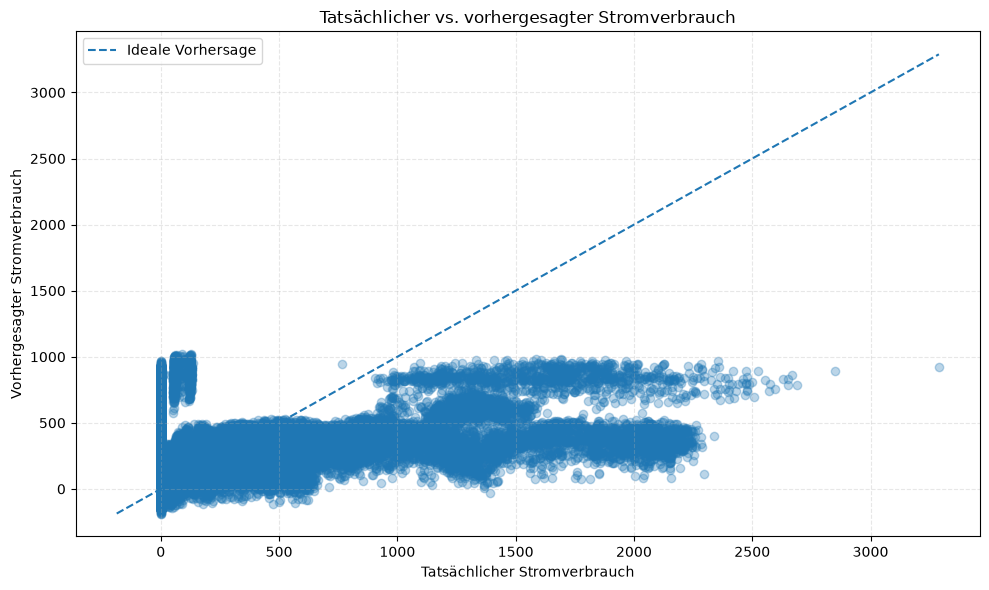

In [ ]:
# =================================================================
# Phase 35.2 – Tatsächliche vs. vorhergesagte Werte
# Zweck: Grafische Bewertung des Originalmodells
# =================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_original,
    alpha=0.3
)

# Ideale Vorhersage: y = x
min_value = min(
    y_test.min(),
    y_pred_original.min()
)

max_value = max(
    y_test.max(),
    y_pred_original.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1.5,
    label="Ideale Vorhersage"
)

plt.xlabel("Tatsächlicher Stromverbrauch")
plt.ylabel("Vorhergesagter Stromverbrauch")
plt.title("Tatsächlicher vs. vorhergesagter Stromverbrauch")

plt.legend()
plt.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

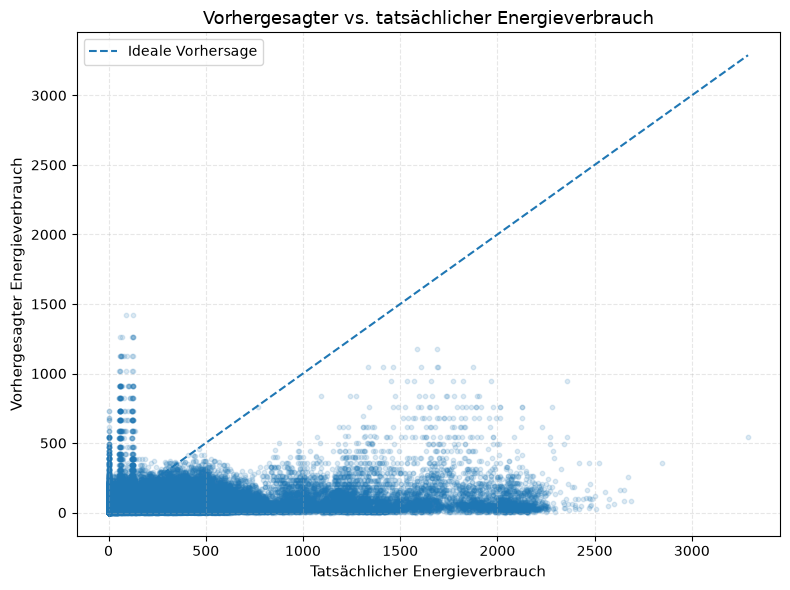

In [ ]:
# =================================================================
# Phase 35.4 – Visualisierung: Vorhersage vs. tatsächlicher Wert
# Zweck: Grafische Bewertung der Modellgüte
# =================================================================

import matplotlib.pyplot as plt

# Gleiche Variable wie im ursprünglichen Modell
y_test_original = y_test

plt.figure(figsize=(8, 6))

# Tatsächliche vs. vorhergesagte Werte
plt.scatter(
    y_test_original,
    y_pred_original,
    alpha=0.15,
    s=10
)

# Ideale Vorhersage: vorhergesagter Wert = tatsächlicher Wert
max_val = max(
    y_test_original.max(),
    y_pred_original.max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    linewidth=1.5,
    label="Ideale Vorhersage"
)

plt.title(
    "Vorhergesagter vs. tatsächlicher Energieverbrauch",
    fontsize=13
)

plt.xlabel(
    "Tatsächlicher Energieverbrauch",
    fontsize=11
)

plt.ylabel(
    "Vorhergesagter Energieverbrauch",
    fontsize=11
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

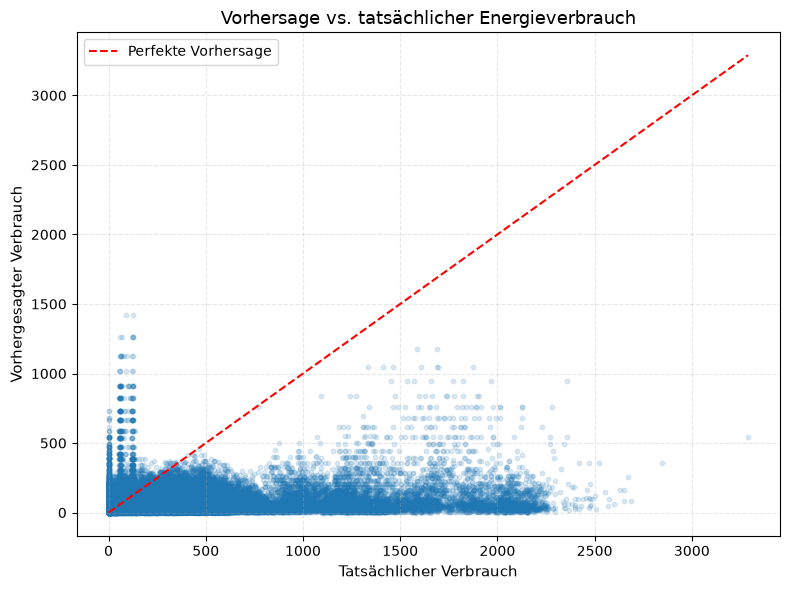

In [ ]:
# =================================================================
# Phase 35.5 – Visualisierung: Vorhersage vs. tatsächlicher Wert
# Zweck: Grafische Bewertung der Modellgüte
# =================================================================

# Anciennes variables conservées pour garder le même graphique
y_test_original = y_test
y_pred_original = y_pred_log_original

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_original,
    y_pred_original,
    alpha=0.15,
    s=10
)

max_val = max(
    y_test_original.max(),
    y_pred_original.max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Perfekte Vorhersage"
)

plt.title(
    "Vorhersage vs. tatsächlicher Energieverbrauch",
    fontsize=13
)

plt.xlabel(
    "Tatsächlicher Verbrauch",
    fontsize=11
)

plt.ylabel(
    "Vorhergesagter Verbrauch",
    fontsize=11
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

Features Engineering 

In [290]:
# =================================================================
# Phase 36 – Feature Engineering
# Zweck: Erweiterung der Eingangsvariablen
# =================================================================

import pandas as pd
import numpy as np

query_features = """
SELECT
    `timestamp`,
    square_feet,
    year_built,
    floor_count,
    air_temperature,
    dew_temperature,
    wind_speed,
    sea_level_pressure,
    meter_reading
FROM train_full
WHERE meter = 0
  AND square_feet IS NOT NULL
  AND meter_reading IS NOT NULL
LIMIT 100000;
"""

df_fe = pd.read_sql(query_features, connection)

print("Anzahl Datensätze:", len(df_fe))
display(df_fe.head())

C:\Users\MamadouDianDiallo\AppData\Local\Temp\ipykernel_7824\313443998.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fe = pd.read_sql(query_features, connection)


Anzahl Datensätze: 100000


,timestamp,square_feet,year_built,floor_count,air_temperature,dew_temperature,wind_speed,sea_level_pressure,meter_reading
0,2016-01-01 00:00:00,7432,2008,None,25.0,20.0,0.0,1019.7,0.0
1,2016-01-01 01:00:00,7432,2008,None,24.4,21.1,1.5,1020.2,0.0
2,2016-01-01 02:00:00,7432,2008,None,22.8,21.1,0.0,1020.2,0.0
3,2016-01-01 03:00:00,7432,2008,None,21.1,20.6,0.0,1020.1,0.0
4,2016-01-01 04:00:00,7432,2008,None,20.0,20.0,2.6,1020.0,0.0


In [291]:
# =================================================================
# Phase 36.2 – Zeitbasierte Merkmale
# =================================================================

df_fe["timestamp"] = pd.to_datetime(df_fe["timestamp"])

# Zeitmerkmale erstellen
df_fe["hour"] = df_fe["timestamp"].dt.hour
df_fe["day_of_week"] = df_fe["timestamp"].dt.dayofweek
df_fe["month"] = df_fe["timestamp"].dt.month
df_fe["is_weekend"] = (df_fe["day_of_week"] >= 5).astype(int)

print("Zeitmerkmale wurden erstellt.")

Zeitmerkmale wurden erstellt.


In [292]:
# =================================================================
# Phase 36.3 – Gebäudealter
# =================================================================

df_fe["building_age"] = (
    df_fe["timestamp"].dt.year - df_fe["year_built"]
)

# Unplausible Werte entfernen
df_fe.loc[df_fe["building_age"] < 0, "building_age"] = np.nan

print("Gebäudealter wurde berechnet.")

Gebäudealter wurde berechnet.


In [293]:
# =================================================================
# Phase 36.4 – Finale Features 
# =================================================================

features = [
    "air_temperature",
    "dew_temperature",
    "wind_speed",
    "sea_level_pressure",
    "square_feet",
    "building_age",
    "hour",
    "day_of_week",
    "month",
    "is_weekend"
]

target = "meter_reading"

# Fehlende Werte entfernen
df_model = df_fe[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

print("Anzahl Beobachtungen:", len(df_model))
print("Anzahl Features:", len(features))
print("Features:", features)
print("Part des données conservées :", round(len(df_model) / len(df_fe) * 100, 1), "%")

Anzahl Beobachtungen: 99008
Anzahl Features: 10
Features: ['air_temperature', 'dew_temperature', 'wind_speed', 'sea_level_pressure', 'square_feet', 'building_age', 'hour', 'day_of_week', 'month', 'is_weekend']
Part des données conservées : 99.0 %


In [294]:
# =================================================================
# Phase 37 – Random Forest
# Zweck: Nichtlineares Regressionsmodell
# =================================================================

features = [
    "air_temperature",
    "dew_temperature",
    "wind_speed",
    "sea_level_pressure",
    "square_feet",
    "building_age",
    "hour",
    "day_of_week",
    "month",
    "is_weekend"
]

target = "meter_reading"

df_model = df_fe[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

print("Anzahl Beobachtungen:", len(df_model))
print("Part des données conservées :", round(len(df_model) / len(df_fe) * 100, 1), "%")

Anzahl Beobachtungen: 99008
Part des données conservées : 99.0 %


In [298]:
# =================================================================
# Phase 37 – Train-Test-Split
# Zweck: Einheitliche Datenbasis für alle Modelle
# =================================================================

features = ["air_temperature", "square_feet"]
target = "meter_reading"

# 500.000 reale Strommessungen verwenden
X = df_ml[features].copy()
y = df_ml[target].copy()

# Prüfen
print("Gesamte Beobachtungen:", len(X))

# Train-Test-Split: 80 % / 20 %
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Trainingsdaten:", len(X_train))
print("Testdaten:", len(X_test))

Gesamte Beobachtungen: 500000
Trainingsdaten: 400000
Testdaten: 100000


In [317]:
# =================================================================
# Phase 37 – Random Forest
# Zweck: Nichtlineares Regressionsmodell    #supp############
# =================================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Trainingsdaten:", len(X_train))
print("Testdaten:", len(X_test))

Trainingsdaten: 400000
Testdaten: 100000


In [318]:
# Cellule 37.2
# Random-Forest-Modell erstellen
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Modell trainieren
rf_model.fit(X_train, y_train)

# Vorhersagen
y_pred_rf = rf_model.predict(X_test)

print("Random-Forest-Modell wurde trainiert.")

Random-Forest-Modell wurde trainiert.


In [310]:
# =================================================================
# Phase 37.3 – Bewertung des Random-Forest-Modells
# =================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("-------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

Random Forest
-------------
MAE : 151.0
RMSE: 259.05
R²  : 0.5668


In [323]:
linear_model_fe = LinearRegression()
linear_model_fe.fit(X_train, y_train)

y_pred_linear_fe = linear_model_fe.predict(X_test)

mae_linear_fe = mean_absolute_error(y_test, y_pred_linear_fe)
rmse_linear_fe = np.sqrt(mean_squared_error(y_test, y_pred_linear_fe))
r2_linear_fe = r2_score(y_test, y_pred_linear_fe)

print("Régression linéaire (mêmes features)")
print("MAE :", round(mae_linear_fe, 2))
print("RMSE:", round(rmse_linear_fe, 2))
print("R²  :", round(r2_linear_fe, 4))

Régression linéaire (mêmes features)
MAE : 230.26
RMSE: 359.67
R²  : 0.1649


In [326]:
# =================================================================
# Phase 38 – Modellvergleich
# =================================================================

from sklearn.linear_model import LinearRegression

# Lineares Modell
linear_model_fe = LinearRegression()
linear_model_fe.fit(X_train, y_train)

y_pred_linear_fe = linear_model_fe.predict(X_test)

# Bewertung lineares Modell
mae_linear_fe = mean_absolute_error(y_test, y_pred_linear_fe)

rmse_linear_fe = np.sqrt(
    mean_squared_error(y_test, y_pred_linear_fe)
)

r2_linear_fe = r2_score(
    y_test,
    y_pred_linear_fe
)

In [332]:
# Ergebnisse vergleichen
comparison = pd.DataFrame({
    "Modell": [
        "Lineare Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear_fe,
        mae_rf
    ],
    "RMSE": [
        rmse_linear_fe,
        rmse_rf
    ],
    "R²": [
        r2_linear_fe,
        r2_rf
    ]
})

comparison = comparison.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 4
})

display(comparison)

,Modell,MAE,RMSE,R²
0,Lineare Regression,230.26,359.67,0.1649
1,Random Forest,151.00,259.05,0.5668


In [336]:
# =================================================================
# Phase 39 – Fehleranalyse
# Zweck: Analyse der Vorhersagefehler
# =================================================================

residuals = y_test - y_pred_rf

print("Fehleranalyse – Random Forest")
print("------------------------------")
print("Mittlerer Fehler :", round(residuals.mean(), 2))
print("Mittlerer absoluter Fehler :", round(np.abs(residuals).mean(), 2))

Fehleranalyse – Random Forest
------------------------------
Mittlerer Fehler : -0.6
Mittlerer absoluter Fehler : 151.0


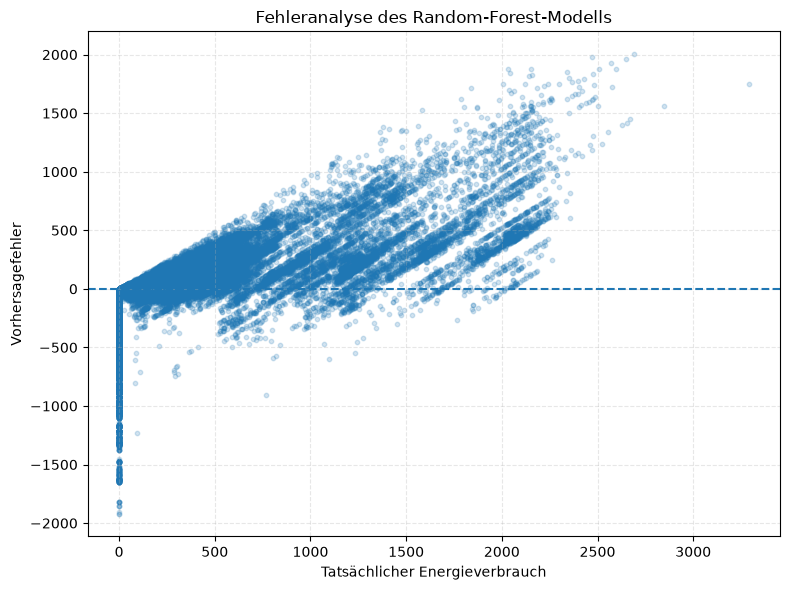

In [337]:
# Cellule 39.2 — Graphique des erreurs

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    residuals,
    alpha=0.2,
    s=10
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Tatsächlicher Energieverbrauch")
plt.ylabel("Vorhersagefehler")
plt.title("Fehleranalyse des Random-Forest-Modells")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()